In [29]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import tensorflow as tf
import numpy as np

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

In [14]:
# Load the CSV file with the converted coordinates
file_path = r"C:\Users\Fadilah Thasnim\Desktop\Academics\7 - Semester\8. TARP\Autonomous Car\Car_parking_india_dataset.csv"
df = pd.read_csv(file_path)
df

,Carpark Name,Latitude,Longitude
0,1st cross street,12.931924,80.133251
1,A.M.S. PARKING STAND,12.951716,80.142994
2,Agastheeswarar Temple Car Parking,12.885959,80.114045
3,AKN Vijayalakshmi Parking Stand,12.939596,80.131390
4,Amet Private Parking,12.857737,80.238945
...,...,...,...
67,Vinoth car parking,12.898596,80.185193
68,Visitors Car Parking,13.071849,80.236404
69,Vk cars garage,12.913853,80.197157
70,VNR TWO WHEELER PARKING,12.905237,80.093647


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Carpark Name  72 non-null     object 
 1   Latitude      72 non-null     float64
 2   Longitude     72 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.8+ KB


C:\Users\Fadilah Thasnim\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Fadilah Thasnim\AppData\Local\Temp\ipykernel_18044\2854877100.py:30: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[0, 0].scatter(X[:, 1], X[:, 0], c=map_labels_to_colors(df['kmeans_labels'].values), cmap='viridis')
C:\Users\Fadilah Thasnim\AppData\Local\Temp\ipykernel_18044\2854877100.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[0, 1].scatter(X[:, 1], X[:, 0], c=map_labels_to_colors(df['gmm_labels'].values), cmap='viridis')
C:\Users\Fadilah Thasnim\AppData\Local\Temp\ipykernel_18044\2854877100.py:34: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[1, 0].scatter(

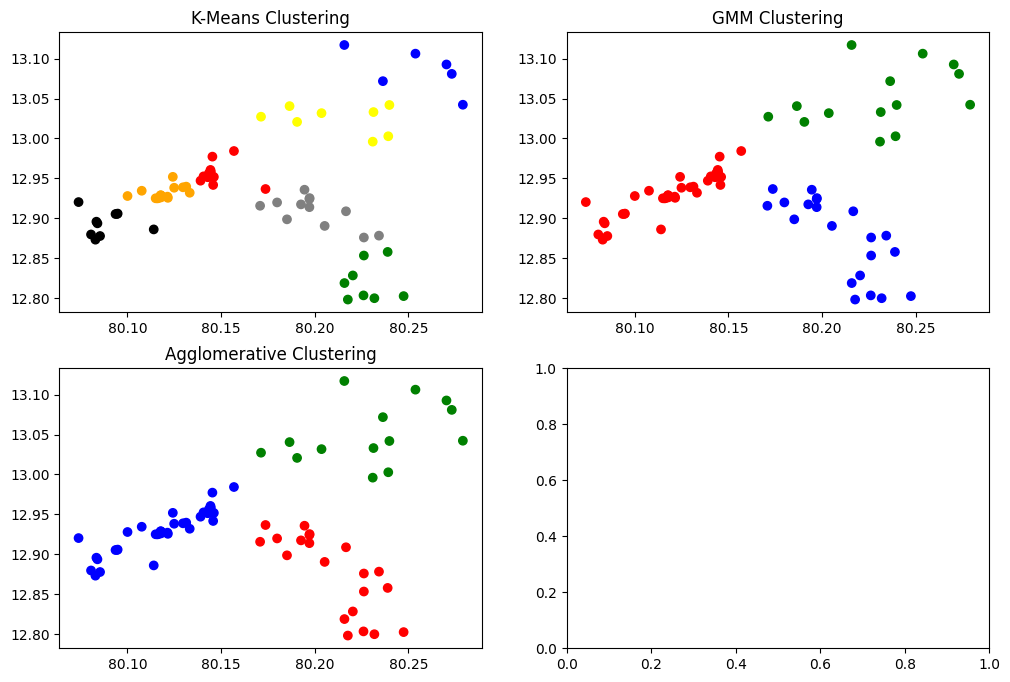

In [25]:
X = df[['Latitude', 'Longitude']].values

# Train K-Means clustering model
kmeans = KMeans(n_clusters=7, random_state=42)
kmeans.fit(X)
df['kmeans_labels'] = kmeans.labels_

# Train Gaussian Mixture Model (GMM) clustering model
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X)
df['gmm_labels'] = gmm.predict(X)

# Train Agglomerative Clustering model
agg = AgglomerativeClustering(n_clusters=3)
agg.fit(X)
df['agg_labels'] = agg.labels_

# Train DBSCAN clustering model
dbscan = DBSCAN(eps=0.3, min_samples=10)
dbscan.fit(X)
df['dbscan_labels'] = dbscan.labels_

# Visualization
colors = ['red', 'green', 'blue', 'black', 'grey', 'yellow', 'orange']

# Map labels to colors
map_labels_to_colors = np.vectorize(lambda x: colors[x])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].scatter(X[:, 1], X[:, 0], c=map_labels_to_colors(df['kmeans_labels'].values), cmap='viridis')
axes[0, 0].set_title('K-Means Clustering')
axes[0, 1].scatter(X[:, 1], X[:, 0], c=map_labels_to_colors(df['gmm_labels'].values), cmap='viridis')
axes[0, 1].set_title('GMM Clustering')
axes[1, 0].scatter(X[:, 1], X[:, 0], c=map_labels_to_colors(df['agg_labels'].values), cmap='viridis')
axes[1, 0].set_title('Agglomerative Clustering')

plt.show()

In [26]:
from sklearn.metrics import silhouette_score

# Calculate silhouette scores
kmeans_silhouette_score = silhouette_score(X, df['kmeans_labels'])
gmm_silhouette_score = silhouette_score(X, df['gmm_labels'])
agg_silhouette_score = silhouette_score(X, df['agg_labels'])

print("K-Means Silhouette Score:", kmeans_silhouette_score)
print("GMM Silhouette Score:", gmm_silhouette_score)
print("Agglomerative Clustering Silhouette Score:", agg_silhouette_score)

K-Means Silhouette Score: 0.5187229801526113
GMM Silhouette Score: 0.5517554927105134
Agglomerative Clustering Silhouette Score: 0.5517554927105134


In [27]:
# Take input of latitude and longitude as floats

##latitude = 12.931924
##longitude = 80.133251
latitude = float(input("Enter Latitude: "))  # e.g., 12.931924
longitude = float(input("Enter Longitude: "))  # e.g., 80.133251

# Create a new data point with the input latitude and longitude
new_data = np.array([[latitude, longitude]])

# Predict the cluster label for the new data point using the trained K-Means model
predicted_label = kmeans.predict(new_data)

# Print the predicted cluster label
print("Predicted Cluster Label:", predicted_label[0])

# Extract the addresses in the predicted cluster
predicted_cluster_label = predicted_label[0]
carpark_in_predicted_cluster = df[df['kmeans_labels'] == predicted_cluster_label]['Carpark Name']

# Print the addresses in the predicted cluster
print("Addresses in Predicted Cluster:")
for carpark in carpark_in_predicted_cluster:
    print(carpark)


Enter Latitude: 12.931924
Enter Longitude: 80.133251
Predicted Cluster Label: 6
Addresses in Predicted Cluster:
1st cross street
AKN Vijayalakshmi Parking Stand
Bike Parking
GRT CAR PARKING
KB CAR PARKING RENT
M.R.K Stand
Parking
QH Talbros Bus Stop
Railway Two Wheeler Parking East
RTO TAMBARAM
Tambaram railway premium two wheeler parking 24hours
Tambaram Railway Station
Tambaram Railway Station Car Parking
Tambaram Sanatorium Bike Stand
Tambaram two wheeler parking
Vasantha Bhavan Parking


In [ ]:
import geopy.distance

# Calculate distances between input latitude/longitude and all addresses in the dataset
pune_EV['distance'] = pune_EV.apply(lambda row: geopy.distance.distance((latitude, longitude),
                                                                     (row['latitude'], row['longitude'])).km, axis=1)

# Find the address with the minimum distance
nearest_address = pune_EV.loc[pune_EV['distance'].idxmin(), 'address']

# Print the nearest address
print("Nearest Address:")
print(nearest_address)

In [36]:


# Prepare the data for clustering
X = df[['Latitude', 'Longitude']]

# Train K-Means clustering model
kmeans = KMeans(n_clusters=3, random_state=42)
df['kmeans_labels'] = kmeans.fit_predict(X)

# Calculate silhouette score for K-Means
silhouette_avg = silhouette_score(X, df['kmeans_labels'])
print(f'Silhouette Score for K-Means: {silhouette_avg:.3f}')

# Define a Keras model for demonstration
model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(10, activation='relu'),
    layers.Dense(3, activation='softmax')  # Assuming 3 clusters
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Dummy training just for illustration
X_train, X_test, y_train, y_test = train_test_split(X, df['kmeans_labels'], test_size=0.2, random_state=42)
model.fit(X_train, y_train, epochs=10, verbose=0)

# Evaluate the Keras model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Keras Model Accuracy: {test_accuracy:.7f}')

# Function to get the best three spots
def get_best_spots(latitude, longitude, df, kmeans):
    new_data = np.array([[latitude, longitude]])
    predicted_label = kmeans.predict(new_data)[0]
    
    # Extract the car parks in the predicted cluster
    carparks_in_predicted_cluster = df[df['kmeans_labels'] == predicted_label]
    
    # Calculate distances to the new point
    carparks_in_predicted_cluster['Distance'] = np.sqrt((carparks_in_predicted_cluster['Latitude'] - latitude) ** 2 + 
                                                          (carparks_in_predicted_cluster['Longitude'] - longitude) ** 2)

    # Get the top 3 closest car parks
    best_spots = carparks_in_predicted_cluster.nsmallest(3, 'Distance')

    return best_spots[['Carpark Name', 'Distance']]

# Example usage
#  12.9357361 , 80.1312777
latitude = 12.9357361 # Input latitude
longitude = 80.131277  # Input longitude
best_spots = get_best_spots(latitude, longitude, df, kmeans)

print("Best 3 Carparks:")
print(best_spots)



C:\Users\Fadilah Thasnim\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Silhouette Score for K-Means: 0.442
Keras Model Accuracy: 0.0000000
Best 3 Carparks:
                      Carpark Name  Distance
3  AKN Vijayalakshmi Parking Stand  0.003862
0                 1st cross street  0.004293
1             A.M.S. PARKING STAND  0.019815


C:\Users\Fadilah Thasnim\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
C:\Users\Fadilah Thasnim\AppData\Local\Temp\ipykernel_18044\1862243996.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  carparks_in_predicted_cluster['Distance'] = np.sqrt((carparks_in_predicted_cluster['Latitude'] - latitude) ** 2 +


In [34]:
# Step to convert the model to TensorFlow Lite
model.save('parking_model_not_final.h5')  # Save the model
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('parking_model_not_final.tflite', 'wb') as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\FADILA~1\AppData\Local\Temp\tmpoqiktxpa\assets


INFO:tensorflow:Assets written to: C:\Users\FADILA~1\AppData\Local\Temp\tmpoqiktxpa\assets


In [ ]:
'''
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

# Sample DataFrame
data = {
    'Carpark Name': ['1st cross street', 'A.M.S. PARKING STAND', 'Agastheeswarar Temple Car Parking', 
                     'AKN Vijayalakshmi Parking Stand', 'Amet Private Parking'],
    'Latitude': [12.931924, 12.951716, 12.885959, 12.939596, 12.857737],
    'Longitude': [80.133251, 80.142994, 80.114045, 80.131390, 80.238945]
}
df = pd.DataFrame(data)

'''

Silhouette Score for DBSCAN: 0.099


<Axes: xlabel='Longitude', ylabel='Latitude'>

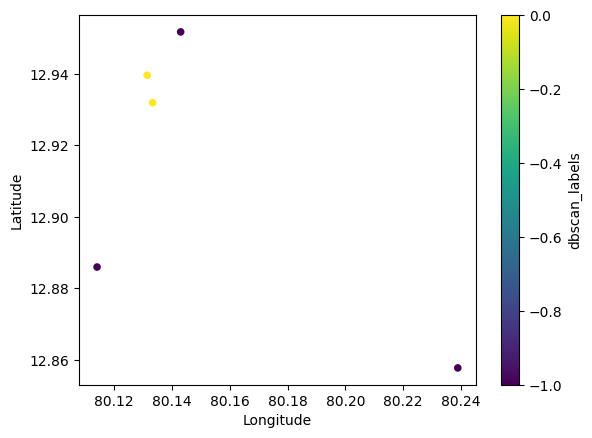

In [37]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Prepare the data for clustering
X = df[['Latitude', 'Longitude']].values

# Train DBSCAN model (use tuned eps and min_samples values)
dbscan = DBSCAN(eps=0.01, min_samples=2)
df['dbscan_labels'] = dbscan.fit_predict(X)

# Calculate silhouette score for DBSCAN
silhouette_avg = silhouette_score(X, df['dbscan_labels'])
print(f'Silhouette Score for DBSCAN: {silhouette_avg:.3f}')

# Visualize the DBSCAN clustering result
df.plot.scatter(x='Longitude', y='Latitude', c='dbscan_labels', colormap='viridis')


In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Filter out noise points labeled as -1 in DBSCAN
df_filtered = df[df['dbscan_labels'] != -1]

# Prepare the data for Random Forest classification
X_rf = df_filtered[['Latitude', 'Longitude']].values
y_rf = df_filtered['dbscan_labels'].values

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate the model
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Random Forest Model Accuracy: {accuracy:.3f}')


Random Forest Model Accuracy: 1.000


In [39]:
# Prepare the input features (latitude, longitude)
X = df[['Latitude', 'Longitude']].values

# Dummy target values (for regression we could use nearby parking spots or distances)
# In this example, we assume the target is the coordinates themselves (identity regression)
y = X  # Normally, the target would be based on proximity calculations, but using X as a placeholder

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data (important for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the TensorFlow model (regression model to predict latitude, longitude)
class NearestParksModel(tf.keras.Model):
    def __init__(self):
        super(NearestParksModel, self).__init__()
        self.dense = tf.keras.layers.Dense(2, activation='linear')  # Output layer predicting lat and long

    def call(self, inputs):
        return self.dense(inputs)

# Create and compile the model
model = NearestParksModel()
model.build((None, 2))  # Input shape of (None, 2) for latitude and longitude


NameError: name 'StandardScaler' is not defined

NameError: name 'X_test_scaled' is not defined